Nro de itens: 25
Nro de combinacoes (Brute Force): 33554431
Tempo Brute force: 1113.0079553127289
Individuo Brute Force: 0b0001111110010111000010011, Valor: 825
Tempo AG: 9.266597986221313
Individuo AG: 0b1001111010010111011000001, Valor: 761


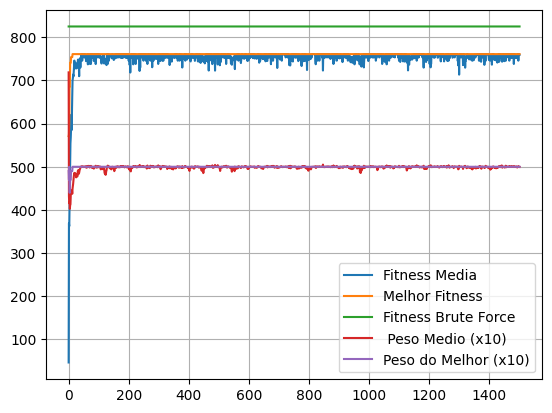

In [3]:
"""
Autor: Victor Barros Coch Adaptado de SomaTarget.py
Trabalho 1 - Problema da Mochila
"""
!pip install bitstring

from matplotlib import pyplot as plt
import time


from random import randint , random , getrandbits
from operator import add
from functools import reduce
from bitstring import BitArray

def individual(length , rand=True):
    #Cria um membro da populacao, array de bits aleatorios
    if rand:
        return BitArray(uint=getrandbits(length) ,length=length)
    else:
        return BitArray(length)

def population(count, length):
    #Cria a populacao
    return [ individual(length) for x in range(count) ]

def fitness(individual , itens , peso_max):
    """
    O fitness do individuo sera a soma dos valores contidos na mochila. ZERO no caso de ultrapassar o peso maximo.
    """

    #Valores iniciais
    peso = 0
    valor = 0

    #Para cada bit
    for i,x in enumerate(individual):
        #Se estiver contido na mochila
        if x :
            peso += itens[i][0]
            valor += itens[i][1]

            #Se exceder o peso maximo
            if peso > peso_max:
                return 0
    return valor

def peso(individual , itens):
    peso =0
    for i,x in enumerate(individual):
        if x:
            peso+=itens[i][0]
    return peso


def media_fitness(pop, itens, peso_max):
    #Media de fitness da populacao
    summed = reduce(add, (fitness(x, itens, peso_max) for x in pop))
    sum_peso = 10*reduce(add, (peso(x,itens) for x in pop))
    len_ = len(pop)*1.0
    return (summed/len_, sum_peso/len_)

def best_fitness(pop, itens, peso_max):
    #Melhor fitness da populacao
    graded = [(x, fitness(x, itens, peso_max)) for x in pop]
    best = max(graded, key=lambda graded:graded[1])

    return (best[1], 10*peso(best[0], itens))

def evolve(pop, itens, peso_max, elite=5, r_parents=0.4, mutate=0.01):
    #Tabula cada individuo e o seu fitness
    graded = [(fitness(x, itens, peso_max), x) for x in pop]

    #Ordena for fitness
    graded = sorted(graded, key=lambda graded: graded[0], reverse=True)

    #Pais
    parents_length = int(len(graded)*r_parents)

    #Elitismo
    if elite:
        parents = [x[1] for x in graded][0:elite]
    else:
        parents = []

    #Roleta
    sum_fit = reduce(add, (x[0] for x in graded))
    while len(parents) < parents_length:
        pick = random ()
        acum_fit = 0
        for i, (fit, individual) in enumerate(graded):
            acum_fit += fit/sum_fit #Distribuicao acumulativa normalizada

            if acum_fit > pick:
                parents.append(individual)
                break

    parents_length = len(parents)
    #descobre quantos filhos terao que ser gerados alem da elite e aleatorios
    desired_length = len(pop) - parents_length
    children = []
    #comeca a gerar filhos que faltam
    while len(children) < desired_length:
        #escolhe pai e mae no conjunto de pais
        male = randint(0, parents_length -1)
        female = randint(0, parents_length -1)
        if male != female:
            male = parents[male]
            female = parents[female]
            half = randint(2,len(male))
            #gera filho metade de cada
            child = male[:half] + female[half:]
            #adiciona novo filho a lista de filhos
            children.append(child)

    #Adiciona lista de filhos na nova populacao
    parents.extend(children)
    # mutate some individuals
    for i, individual in enumerate(parents):
        if mutate > random():
            pos_to_mutate = randint(0, len(individual)-1)
            individual.invert(pos_to_mutate)
    return parents

def run_bruteforce(itens, peso_max):
    n_itens = len(itens)
    #Individuo inicial (todos zeros)
    individuo = BitArray(n_itens)
    #Individuo final (todos uns)
    end = BitArray(n_itens)
    end.invert()
    #Contador de combinacoes
    combos = 0

    #Verifica todos possiveis individuos
    best = (0,individuo)
    while individuo.uint < end.uint:
        individuo = BitArray(uint = individuo.uint+1, length=n_itens)
        fit = fitness(individuo ,itens ,peso_max)

        if fit > best [0]:
            best = (fit, individuo)
        combos += 1

    print("Nro de combinacoes (Brute Force): "+str(combos))
    return(best)


#Definindo itens possiveis (peso,valor)
itens = [(6 ,20) ,(5 ,12) ,(1 ,11) ,(1 ,55) ,(3 ,22) ,(8 ,80) ,(2 ,65) ,(3 ,27) ,(7 ,95) ,(17,28) ,(8,39) ,(2,86) ,(14,8) ,(5,84) ,(4,92) ,(3,73) ,(11,20) ,(3,14), (3 ,20) ,(5 ,18) ,(2 ,13) ,(8 ,35) ,(10 ,37) ,(7 ,78) ,(3 ,55)]

#Numero de intens
n_itens = len(itens)
print("Nro de itens: "+str(n_itens)) #Peso maximo da mochila
peso_max = 50

#Calcula valor de validacao com brute force
t0 = time.time()
best = run_bruteforce(itens, peso_max)
t1 = time.time()
print("Tempo Brute force: "+str(t1-t0))
t0 = time.time()

#Tamanho da populacao
p_count = 100

#Criando a populacao
p = population(p_count , n_itens)

#Numero de geracoes para testar
epochs = 1500

#Salva fitness para referencia
media = media_fitness(p, itens, peso_max)
best_f = best_fitness(p, itens, peso_max)
fitness_history = [[media[0]],[media[1]],[best_f[0]],[best_f[1]]] # med fitness|med peso|best fitness|bets peso

for i in range(epochs):
    p = evolve(p, itens , peso_max)
    media = media_fitness(p, itens, peso_max)
    best_f = best_fitness(p, itens, peso_max)
    fitness_history[0].append(media[0])
    fitness_history[1].append(media[1])
    fitness_history[2].append(best_f[0])
    fitness_history[3].append(best_f[1])

t1 = time.time()

print("Individuo Brute Force: "+str(best[1])+", Valor: "+str(best[0]))

print("Tempo AG: "+str(t1-t0))

print("Individuo AG: "+str(sorted(p, key=lambda p:p[0])[-1])+", Valor: " +str(fitness_history[2][-1]))

fig = plt.figure()
ax = plt.axes()

ax.plot(fitness_history[0])
ax.plot(fitness_history[2])
ax.plot([best[0] for i in fitness_history[0]])
ax.plot(fitness_history[1])
ax.plot(fitness_history[3])

ax.legend(["Fitness Media", "Melhor Fitness", "Fitness Brute Force", " Peso Medio (x10)", "Peso do Melhor (x10)"])

ax.grid(True)
plt.show()
